## Install dependencies

In [2]:
!pip -q install \
  "numpy==2.0.2" \
  "pandas==2.2.2" \
  "scikit-learn>=1.3,<1.7" \
  "matplotlib>=3.7,<3.11" \
  "datasets>=2.19,<4" \
  "transformers>=4.41,<5" \
  "evaluate>=0.4,<0.5" \
  "accelerate>=0.30,<2" \
  "tf-keras>=2.16,<2.21"

import sys, numpy, pandas
print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("If you just fixed pandas/numpy conflicts, restart the runtime once before continuing: Runtime > Restart runtime.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 8.8 MB/s eta 0:00:00
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.0.2
Pandas: 2.2.2
If you just fixed pandas/numpy conflicts, restart the runtime once before continuing: Runtime > Restart runtime.


## Imports, configuration, and reproducibility


In [3]:
import os
import random
import re
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, set_seed
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
set_seed(SEED)


DATASET_NAME = 'davanstrien/WELFake'
MAX_ROWS = 12000
TEST_SIZE = 0.15
VAL_SIZE = 0.15
MAX_WORDS = 30000
MAX_SEQUENCE_LEN = 300
BATCH_SIZE_NN = 64
EPOCHS_NN = 4

TRANSFORMER_MODEL = 'distilbert-base-uncased'
MAX_LEN_TRANSFORMER = 256
EPOCHS_TRANSFORMER = 1
BATCH_SIZE_TRANSFORMER = 16

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cpu


## Load and inspect data

The dataset may contain fields such as title, text, and label. The notebook standardizes those fields into:

- `title`
- `text`
- `combined_text`
- `label`

In [4]:
raw = load_dataset(DATASET_NAME)
print(raw)

split_name = 'train' if 'train' in raw else list(raw.keys())[0]
df = raw[split_name].to_pandas()
print('Original shape:', df.shape)
print(df.head())
print(df.columns)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-290868f0a36350(…):   0%|          | 0.00/152M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/72134 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'text', 'label'],
        num_rows: 72134
    })
})
Original shape: (72134, 3)
                                               title  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1                                               None   
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3  Bobby Jindal, raised Hindu, uses story of Chri...   
4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
Index(['title', 'text', 'label'], dtype='object')


In [5]:
possible_title_cols = [c for c in df.columns if c.lower() in ['title', 'headline']]
possible_text_cols = [c for c in df.columns if c.lower() in ['text', 'content', 'article']]
possible_label_cols = [c for c in df.columns if c.lower() in ['label', 'class', 'target']]

TITLE_COL = possible_title_cols[0] if possible_title_cols else None
TEXT_COL = possible_text_cols[0] if possible_text_cols else None
LABEL_COL = possible_label_cols[0] if possible_label_cols else None

print('Detected columns:', {'title': TITLE_COL, 'text': TEXT_COL, 'label': LABEL_COL})

if TEXT_COL is None or LABEL_COL is None:
    raise ValueError('Could not identify text and label columns. Inspect df.columns and update column names manually.')

data = pd.DataFrame()
data['title'] = df[TITLE_COL].fillna('') if TITLE_COL else ''
data['text'] = df[TEXT_COL].fillna('')
data['label'] = df[LABEL_COL].astype(int)

data = data[data['label'].isin([0, 1])].copy()
data['combined_text'] = (data['title'].astype(str) + ' ' + data['text'].astype(str)).str.strip()
data['text_len_words'] = data['combined_text'].str.split().str.len()
data = data[data['combined_text'].str.len() > 20].drop_duplicates(subset=['combined_text'])

if MAX_ROWS is not None and len(data) > MAX_ROWS:
    data = data.sample(n=MAX_ROWS, random_state=SEED).reset_index(drop=True)

print('Prepared shape:', data.shape)
print(data['label'].value_counts(normalize=False).rename({0:'fake', 1:'real'}))
data.head()

Detected columns: {'title': 'title', 'text': 'text', 'label': 'label'}
Prepared shape: (12000, 5)
label
fake    6550
real    5450
Name: count, dtype: int64


,title,text,label,combined_text,text_len_words
0,Trump Sends Crazy-Time Tweet To The Wrong Acc...,Donald Trump retweeted fake news videos in the...,1,Trump Sends Crazy-Time Tweet To The Wrong Acco...,365
1,Japanese PM Abe sends ritual offering to Yasuk...,TOKYO (Reuters) - Japanese Prime Minister Shin...,0,Japanese PM Abe sends ritual offering to Yasuk...,346
2,Illegal Immigrants Could Elect Hillary,Illegal immigrants—along with other noncitizen...,0,Illegal Immigrants Could Elect Hillary Illegal...,934
3,Parents of Terror Victim Sue Chicago-Area Pale...,(AP) CHICAGO — The parents of a yeshiva ...,0,Parents of Terror Victim Sue Chicago-Area Pale...,362
4,U.S. 'disappointed' by India's visa refusal fo...,WASHINGTON (Reuters) - The U.S. State Departme...,0,U.S. 'disappointed' by India's visa refusal fo...,408


## Exploratory data analysis


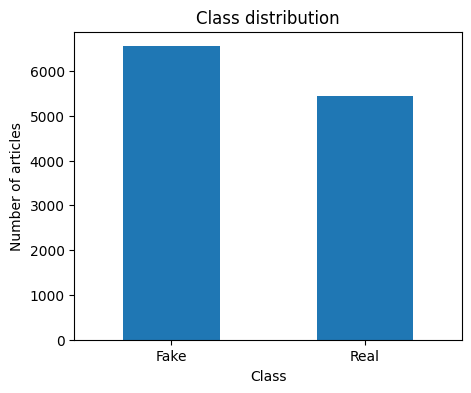

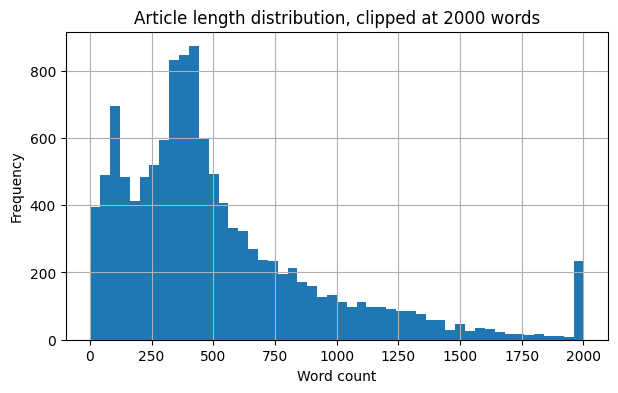

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Fake,6550.0,577.498473,508.809914,16.0,250.0,434.0,790.0,7855.0
Real,5450.0,505.714312,675.228575,2.0,241.0,386.0,563.0,20904.0


In [6]:
label_counts = data['label'].map({0:'Fake', 1:'Real'}).value_counts()
plt.figure(figsize=(5,4))
label_counts.plot(kind='bar')
plt.title('Class distribution')
plt.xlabel('Class')
plt.ylabel('Number of articles')
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(7,4))
data['text_len_words'].clip(upper=2000).hist(bins=50)
plt.title('Article length distribution, clipped at 2000 words')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.show()

data.groupby('label')['text_len_words'].describe().rename(index={0:'Fake',1:'Real'})

## Train/validation/test split

The split is stratified so that fake and real articles remain balanced across train, validation, and test sets.

In [7]:
train_df, temp_df = train_test_split(
    data, test_size=(VAL_SIZE + TEST_SIZE), random_state=SEED, stratify=data['label']
)
relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)
val_df, test_df = train_test_split(
    temp_df, test_size=relative_test_size, random_state=SEED, stratify=temp_df['label']
)

for name, part in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    print(name, part.shape, part['label'].value_counts(normalize=True).round(3).to_dict())

train (8400, 5) {0: 0.546, 1: 0.454}
validation (1800, 5) {0: 0.546, 1: 0.454}
test (1800, 5) {0: 0.546, 1: 0.454}


## Testing helper functions

In [8]:
results = []
prediction_store = {}

def evaluate_predictions(model_name, y_true, y_pred, y_proba=None):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    auc = None
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba)
        except Exception:
            auc = None
    row = {
        'model': model_name,
        'accuracy': acc,
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
        'roc_auc': auc
    }
    results.append(row)
    print(model_name)
    print(pd.DataFrame([row]))
    print('Classification report:')
    print(classification_report(y_true, y_pred, target_names=['Fake', 'Real'], zero_division=0))
    return row

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
    disp.plot(values_format='d')
    plt.title(title)
    plt.show()

## Baseline 1: TF-IDF + Logistic Regression


Training time: 23.63 seconds
TF-IDF + Logistic Regression
                          model  accuracy  macro_precision  macro_recall  \
0  TF-IDF + Logistic Regression  0.918889         0.917682       0.91933   

   macro_f1   roc_auc  
0  0.918366  0.973172  
Classification report:
              precision    recall  f1-score   support

        Fake       0.94      0.91      0.92       983
        Real       0.90      0.92      0.91       817

    accuracy                           0.92      1800
   macro avg       0.92      0.92      0.92      1800
weighted avg       0.92      0.92      0.92      1800



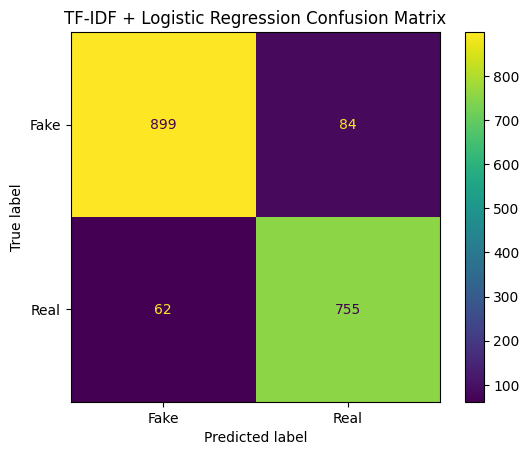

In [9]:
tfidf_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95,
        stop_words='english'
    )),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED))
])

start = time.time()
tfidf_lr.fit(train_df['combined_text'], train_df['label'])
print('Training time:', round(time.time() - start, 2), 'seconds')

lr_pred = tfidf_lr.predict(test_df['combined_text'])
lr_proba = tfidf_lr.predict_proba(test_df['combined_text'])[:,1]
evaluate_predictions('TF-IDF + Logistic Regression', test_df['label'], lr_pred, lr_proba)
plot_confusion(test_df['label'], lr_pred, 'TF-IDF + Logistic Regression Confusion Matrix')
prediction_store['TF-IDF + Logistic Regression'] = lr_pred

## Neural preprocessing for MLP and LSTM

In [ ]:
# to add